# Chapter12, Homework3

## (a)  Plot the observations.

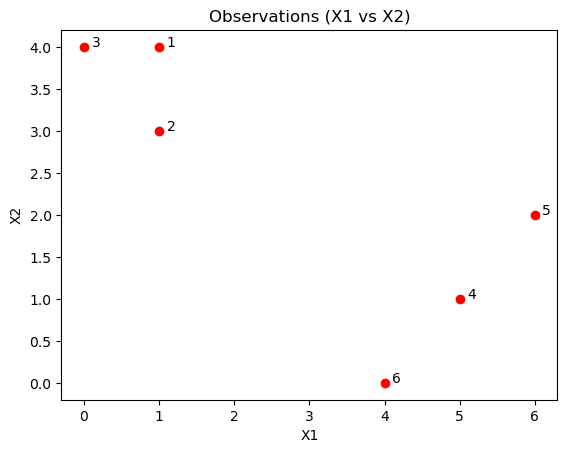

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = np.array([[1,4],[1,3],[0,4],[5,1],[6,2],[4,0]])
obs = np.arange(1,7)

plt.scatter(data[:,0], data[:,1], c='red')
for i, txt in enumerate(obs):
    plt.text(data[i,0]+0.1, data[i,1], str(txt))
plt.title('Observations (X1 vs X2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## (b) Random Initial Cluster Assignment
Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation

In [47]:
np.random.seed(42)
clusters = np.random.choice([1,2], size=len(data))
pd.DataFrame({'Observation': obs, 'Cluster': clusters})

,Observation,Cluster
0,1,1
1,2,2
2,3,1
3,4,1
4,5,1
5,6,2


## (c) Compute Centroids
Compute the centroid for each cluster.

In [48]:
def compute_centroids(data, clusters, K=2):
    centroids = np.array([data[clusters==k].mean(axis=0) for k in range(1, K+1)])
    return centroids

centroids = compute_centroids(data, clusters)
centroids

array([[3.  , 2.75],
       [2.5 , 1.5 ]])

I have 2 clusters (K=2) . Each centroid is the average position of all points in this cluster.

## (d) Reassign Each Observation to Nearest Centroid
Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [49]:
def assign_clusters(data, centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1) + 1

new_clusters = assign_clusters(data, centroids)
pd.DataFrame({'Observation': obs, 'Cluster': new_clusters})

,Observation,Cluster
0,1,1
1,2,1
2,3,1
3,4,2
4,5,1
5,6,2


## (e) Repeat Until Convergence
Repeat (c) and (d) until the answers obtained stop changing.

In [52]:
clusters = new_clusters
for i in range(10):  # limit iterations
    centroids = compute_centroids(data, clusters, K=2)  # make sure K matches
    new_clusters = assign_clusters(data, centroids)
    if np.all(new_clusters == clusters):
        break
    clusters = new_clusters

pd.DataFrame({'Observation': obs, 'Cluster': clusters})


,Observation,Cluster
0,1,1
1,2,1
2,3,1
3,4,2
4,5,2
5,6,2


## (f) Plot Final Clusters
n your plot from (a), color the observations according to the cluster labels obtained.

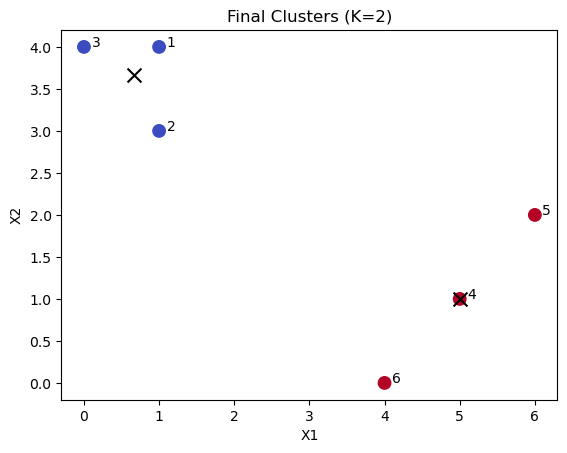

In [53]:
plt.scatter(data[:,0], data[:,1], c=clusters, cmap='coolwarm', s=80)
for i, txt in enumerate(obs):
    plt.text(data[i,0]+0.1, data[i,1], str(txt))
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='x', s=100)
plt.title('Final Clusters (K=2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()